# Organic-Choice Analytics Challenge
### Decoding Indian Consumer Behaviour for Premium Food Products — GreenBazaar

**Organized by:** Sankalp 11.0 – Analytica, National Academy of Agricultural Research Management (NAARM), Hyderabad

**Team:** THINK CORE — Pranav Mishra & Arhan Ansari

---

## 1) Problem Statement

GreenBazaar, one of India's premier premium retail chains (50+ stores across Tier-1, Tier-2, and Tier-3 cities, ₹500+ crore annual revenue), is underperforming in the organic food segment. Organic food currently contributes only **4% of total sales**, well below the industry benchmark of **12%**, despite the Indian organic food market growing at a **25% CAGR** and projected to reach ₹75,000 crore by 2027. This underperformance — driven by misallocated shelf space, generic marketing, poor inventory decisions, and unjustified premium pricing — represents an estimated **₹50 crore in lost annual revenue**.

**Business Question:** Which customers are drawn to premium organic food, and how can GreenBazaar use that understanding to better target marketing, curate shelf space, and manage inventory?

---

## 2) Brief Summary

This notebook addresses the problem through six phases:

**Phase 0 — Data Cleaning & Preparation:** Checked for missing values and duplicates, then detected and treated outliers across key numeric columns using the IQR method to ensure the analysis isn't skewed by extreme values.

**Phase 1 — Exploratory Data Analysis:** Visualized customer distributions, spend patterns, and purchase intent across demographic, economic, and lifestyle variables to understand who GreenBazaar's customers are and how they behave.

**Phase 2 — Feature Engineering & Selection:** Engineered business-meaningful features (e.g., Spend-to-Income Ratio, Eco-Consciousness Score, Convenience Gap) and selected the strongest drivers of organic spend and purchase intent using correlation and importance ranking.

**Phase 3 — Business Problem-Solving Framework:** Built a customer segmentation model (K-Means) that groups customers into actionable personas, then translated each segment into a concrete shelf-placement, marketing, pricing, and inventory action plan.

**Phase 4 — Incisive Insights & Recommendations:** Synthesized data-backed insights and recommendations tied directly back to GreenBazaar's stated ₹50 crore revenue gap, with clear priority guidance on which customer segments to target first.

**Phase 5 — Bonus: Predictive Modeling:** Built a stacking ensemble (Random Forest, XGBoost, CatBoost, LightGBM, and Gradient Boosting as base models with Ridge as the meta-model) to predict Purchase_Intent, included at the end to independently validate the feature selection choices from Phase 3 rather than as a required deliverable.

---

## 3) About the Dataset

The dataset contains survey-style records for **500 GreenBazaar customers** across **26 attributes**, grouped into five categories:

| Category | Attributes |
|---|---|
| **Demographics** | Age, Gender, Education, Marital Status, Household Size |
| **Economic Indicators** | Monthly Income, Num Cars, Num Credit Cards, Electricity Bill |
| **Lifestyle & Awareness** | Health Score, Environmental Awareness, Price Sensitivity, Daily Screen Time, Follows Nutrition Content, Years Smartphone User, Annual Vacations |
| **Location & Access** | City Tier, Region, Distance to Store, Transport Mode, Buys Online Groceries |
| **Target Variables** | **Purchase_Intent** — whether the customer intends to buy organic food (Yes/No) <br> **Weekly_Organic_Spend** — ₹ spent weekly on organic products |

**Dataset shape:** 500 rows × 26 columns
**Prediction targets:** `Purchase_Intent` (classification) and `Weekly_Organic_Spend` (regression) — both central to answering GreenBazaar's business question of *who* to target and *how much* they're likely to spend.

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Phase 0 : Data Cleaning & Preparation

In [ ]:
#Downloading required frameworks & package

!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install xgboost
!pip install catboost
!pip install lightgbm

In [1]:
import pandas as pd;
import numpy as np;
import matplotlib.pyplot as plt;
import seaborn as sns;

## Data Loading

In [2]:
df = pd.read_csv("indian_organic_food(dataset).csv")
print(df)

#Remove unnecessary warnings and messages
import warnings
warnings.filterwarnings('ignore')

     Age  Monthly_Income  Health_Score  Env_Awareness  Price_Sensitivity  \
0     46          166280             4              5                  4   
1     74           55966             1              3                  3   
2     50           76772             1              7                 10   
3     55           43528            10              6                  4   
4     62          171671            10              4                  3   
..   ...             ...           ...            ...                ...   
495   75          279713             8             10                  2   
496   30          125368             8              1                 10   
497   29          145511             2              1                 10   
498   48           71667            10              8                  5   
499   72           70300             2              8                  6   

     Household_Size  Gender  Daily_Screen_Time      Education  \
0                 4  F

## Data Quality Check — Missing Values & Duplicates

In [3]:
missing = df.isnull().sum()
duplicates = df.duplicated().sum()

if missing.sum() == 0:
    print("No missing values")
else:
    print(missing[missing > 0])

if duplicates == 0:
    print("No duplicate values")
else:
    print("Number of duplicate rows:", duplicates)

No missing values
No duplicate values


## Outlier Detection & Treatment (IQR Method)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Age','Monthly_Income','Health_Score','Env_Awareness','Price_Sensitivity',
                 'Household_Size','Daily_Screen_Time','Weekly_Organic_Spend',
                 'Electricity_Bill','Distance_to_Store']

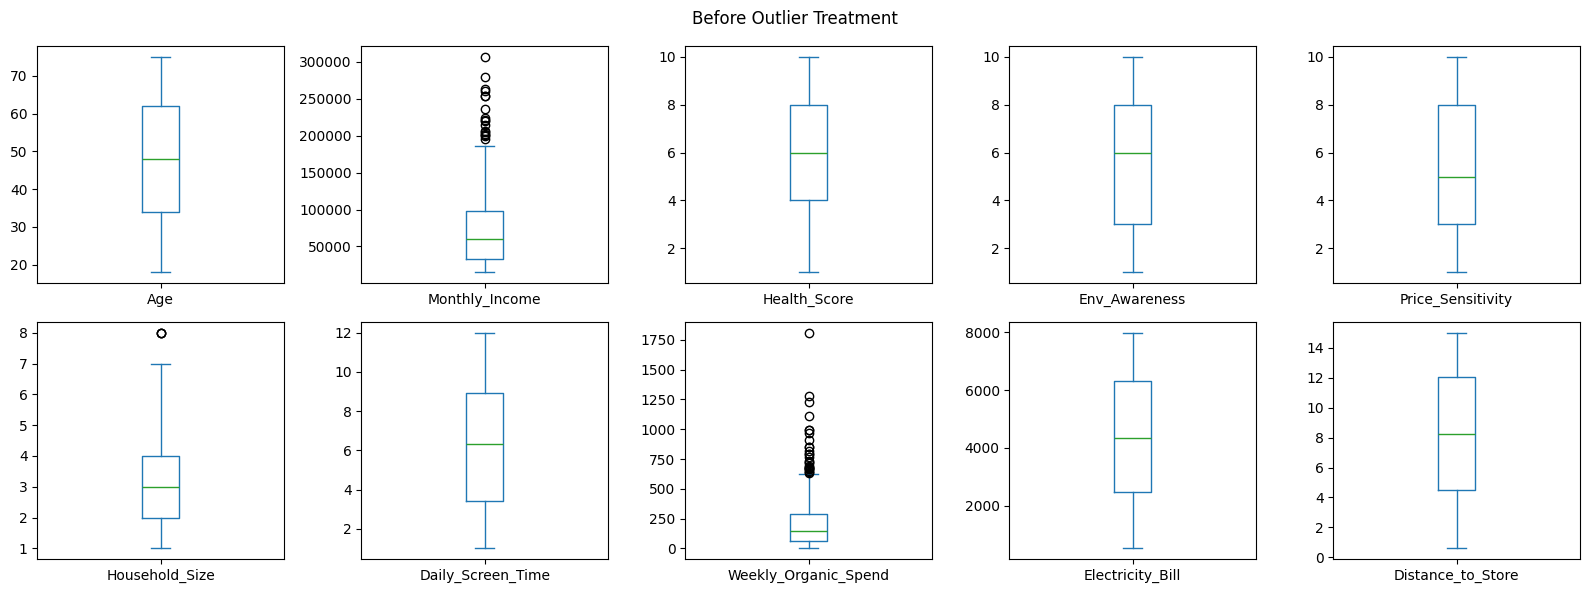

In [5]:
#outlier before Treatment
df[numeric_cols].plot(kind='box', subplots=True, layout=(2,5), figsize=(16,6), title='Before Outlier Treatment')
plt.tight_layout()
plt.show()

In [6]:
# Handling Outliers Using the Interquartile Range (IQR)
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR #lower bound
    upper = Q3 + 1.5 * IQR #upper bound

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    # Cap the outliers to the lower/upper bound
    df[col] = np.clip(df[col], lower, upper)

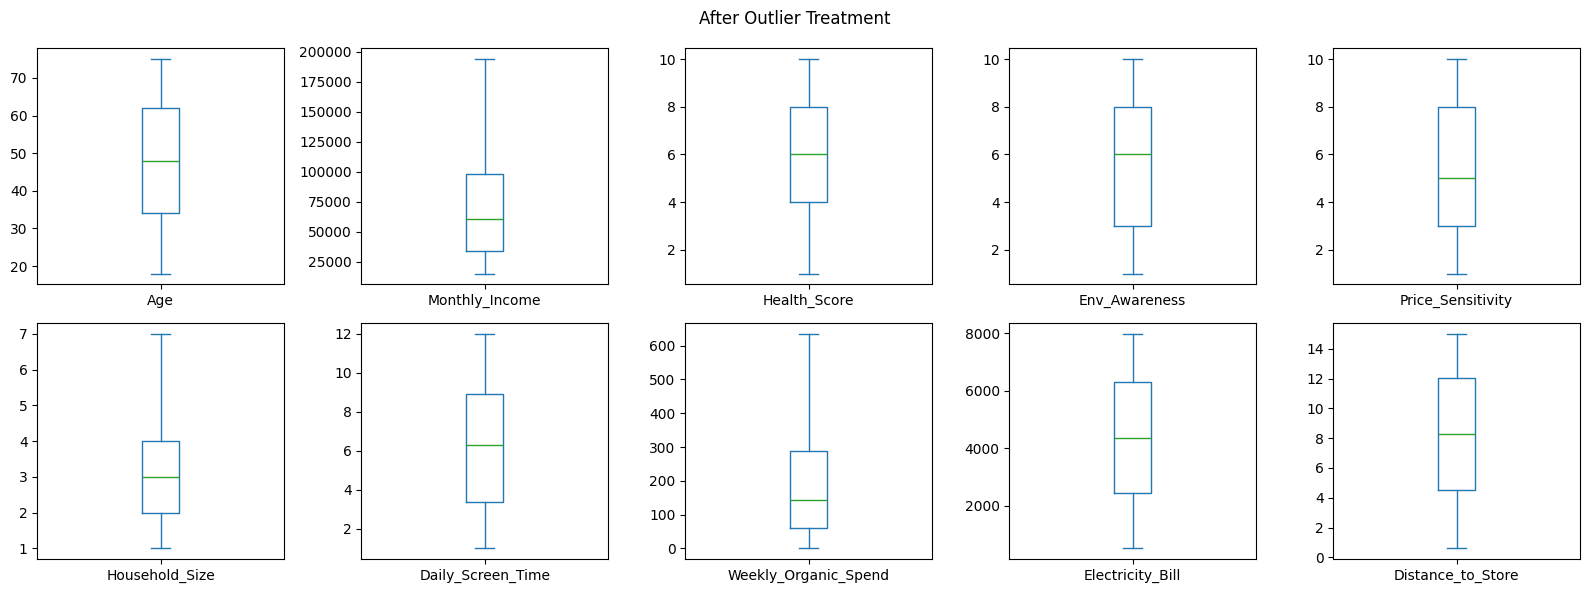

In [7]:
#Outliers After Treatment
df[numeric_cols].plot(kind='box', subplots=True, layout=(2,5), figsize=(16,6), title='After Outlier Treatment')
plt.tight_layout()
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Phase 1 : Exploratory Data Analytics & Visualization

Correlation Heatmap -> Shows how strongly every numeric variable relates to every other, including the two targets — warm colors mean a positive relationship, cool colors mean negative, near-white means little to no relationship.

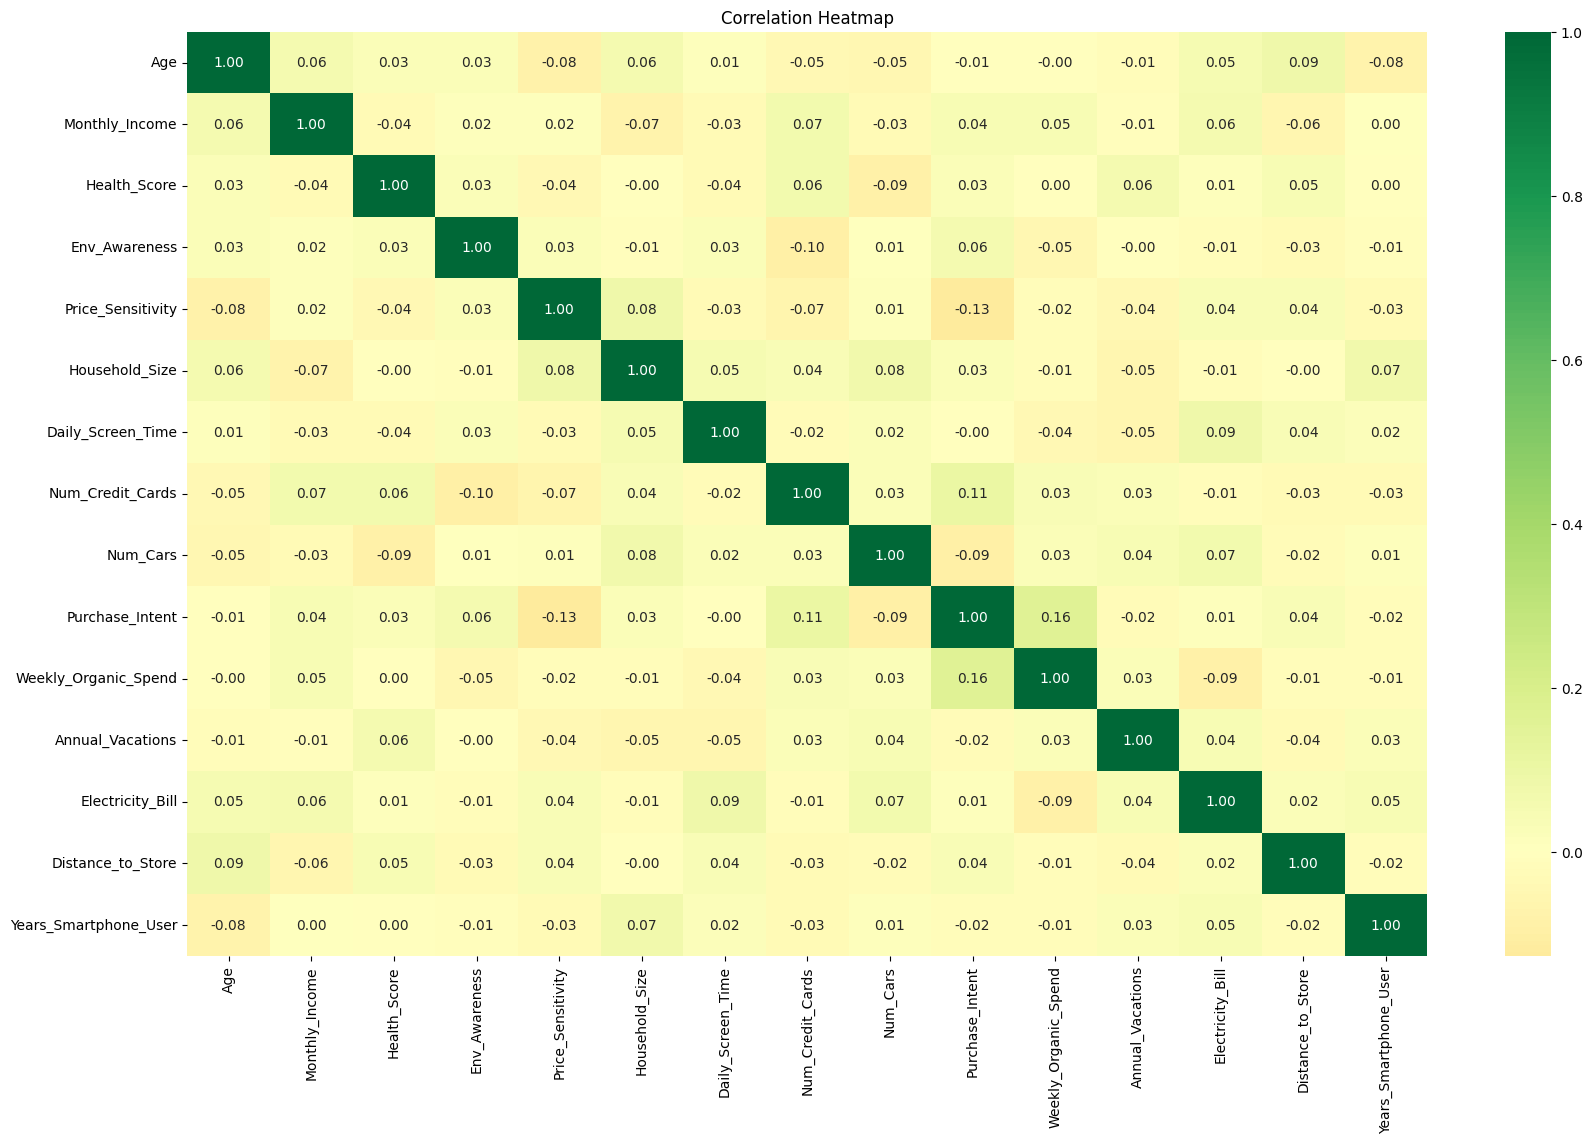

In [8]:
plt.figure(figsize=(20,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Weekly Organic Spend Distribution -> A histogram showing how customer spend is distributed — reveals the data is right-skewed, meaning most customers spend a modest amount while a few high spenders pull the average up.

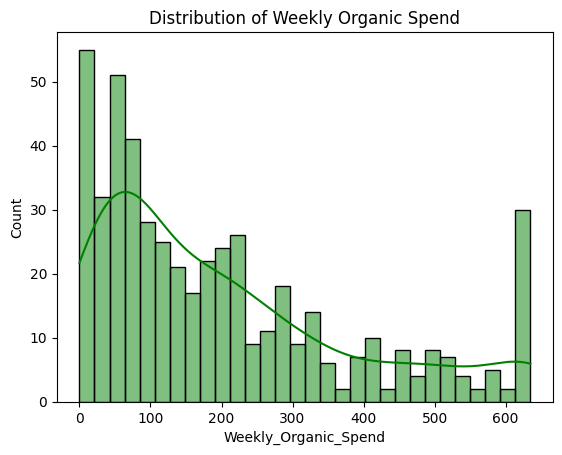

In [9]:
sns.histplot(df['Weekly_Organic_Spend'], bins=30, kde=True, color='green')
plt.title('Distribution of Weekly Organic Spend')
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Monthly Income Distribution -> Shows the spread of customer income levels — gives context on whether the customer base is mostly middle-income, high-income, or mixed.

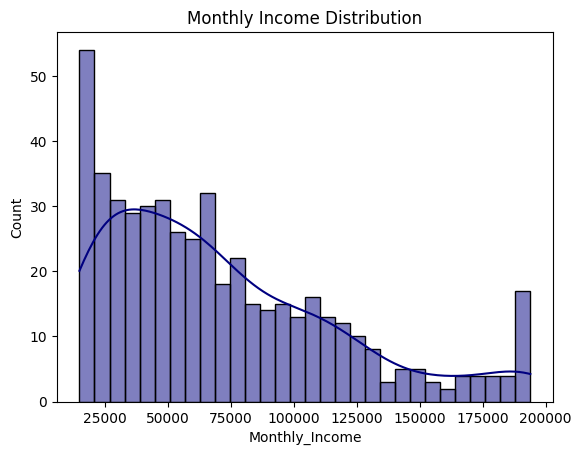

In [10]:
sns.histplot(df['Monthly_Income'], bins=30, kde=True, color='navy')
plt.title('Monthly Income Distribution')
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Avg Weekly Spend: City Tier × Region (Heatmap) : Cross-tabulates spend by both city tier and region at once — pinpoints exactly which tier-region combinations spend the most, more precise than looking at either factor alone.

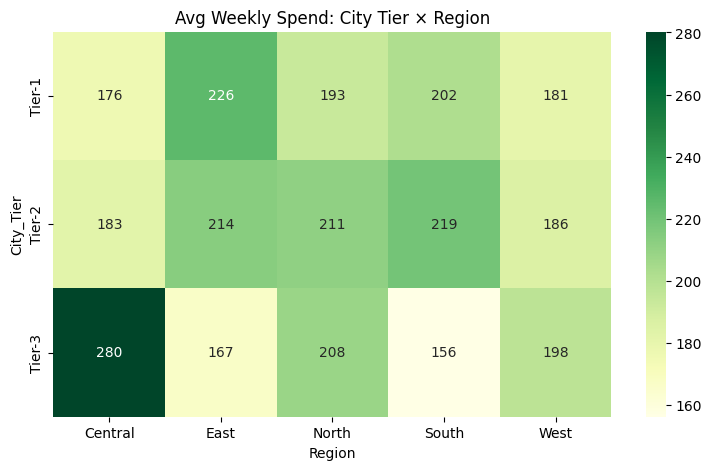

In [11]:
pivot = df.pivot_table(values='Weekly_Organic_Spend', index='City_Tier', columns='Region', aggfunc='mean')
plt.figure(figsize=(9,5))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlGn')
plt.title('Avg Weekly Spend: City Tier × Region')
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Avg Weekly Spend by All Categorical Features -> One combined figure with a bar chart per categorical column (Gender, Education, City Tier, Region, etc.), each showing average spend — lets you scan for spending patterns across every category at a glance.

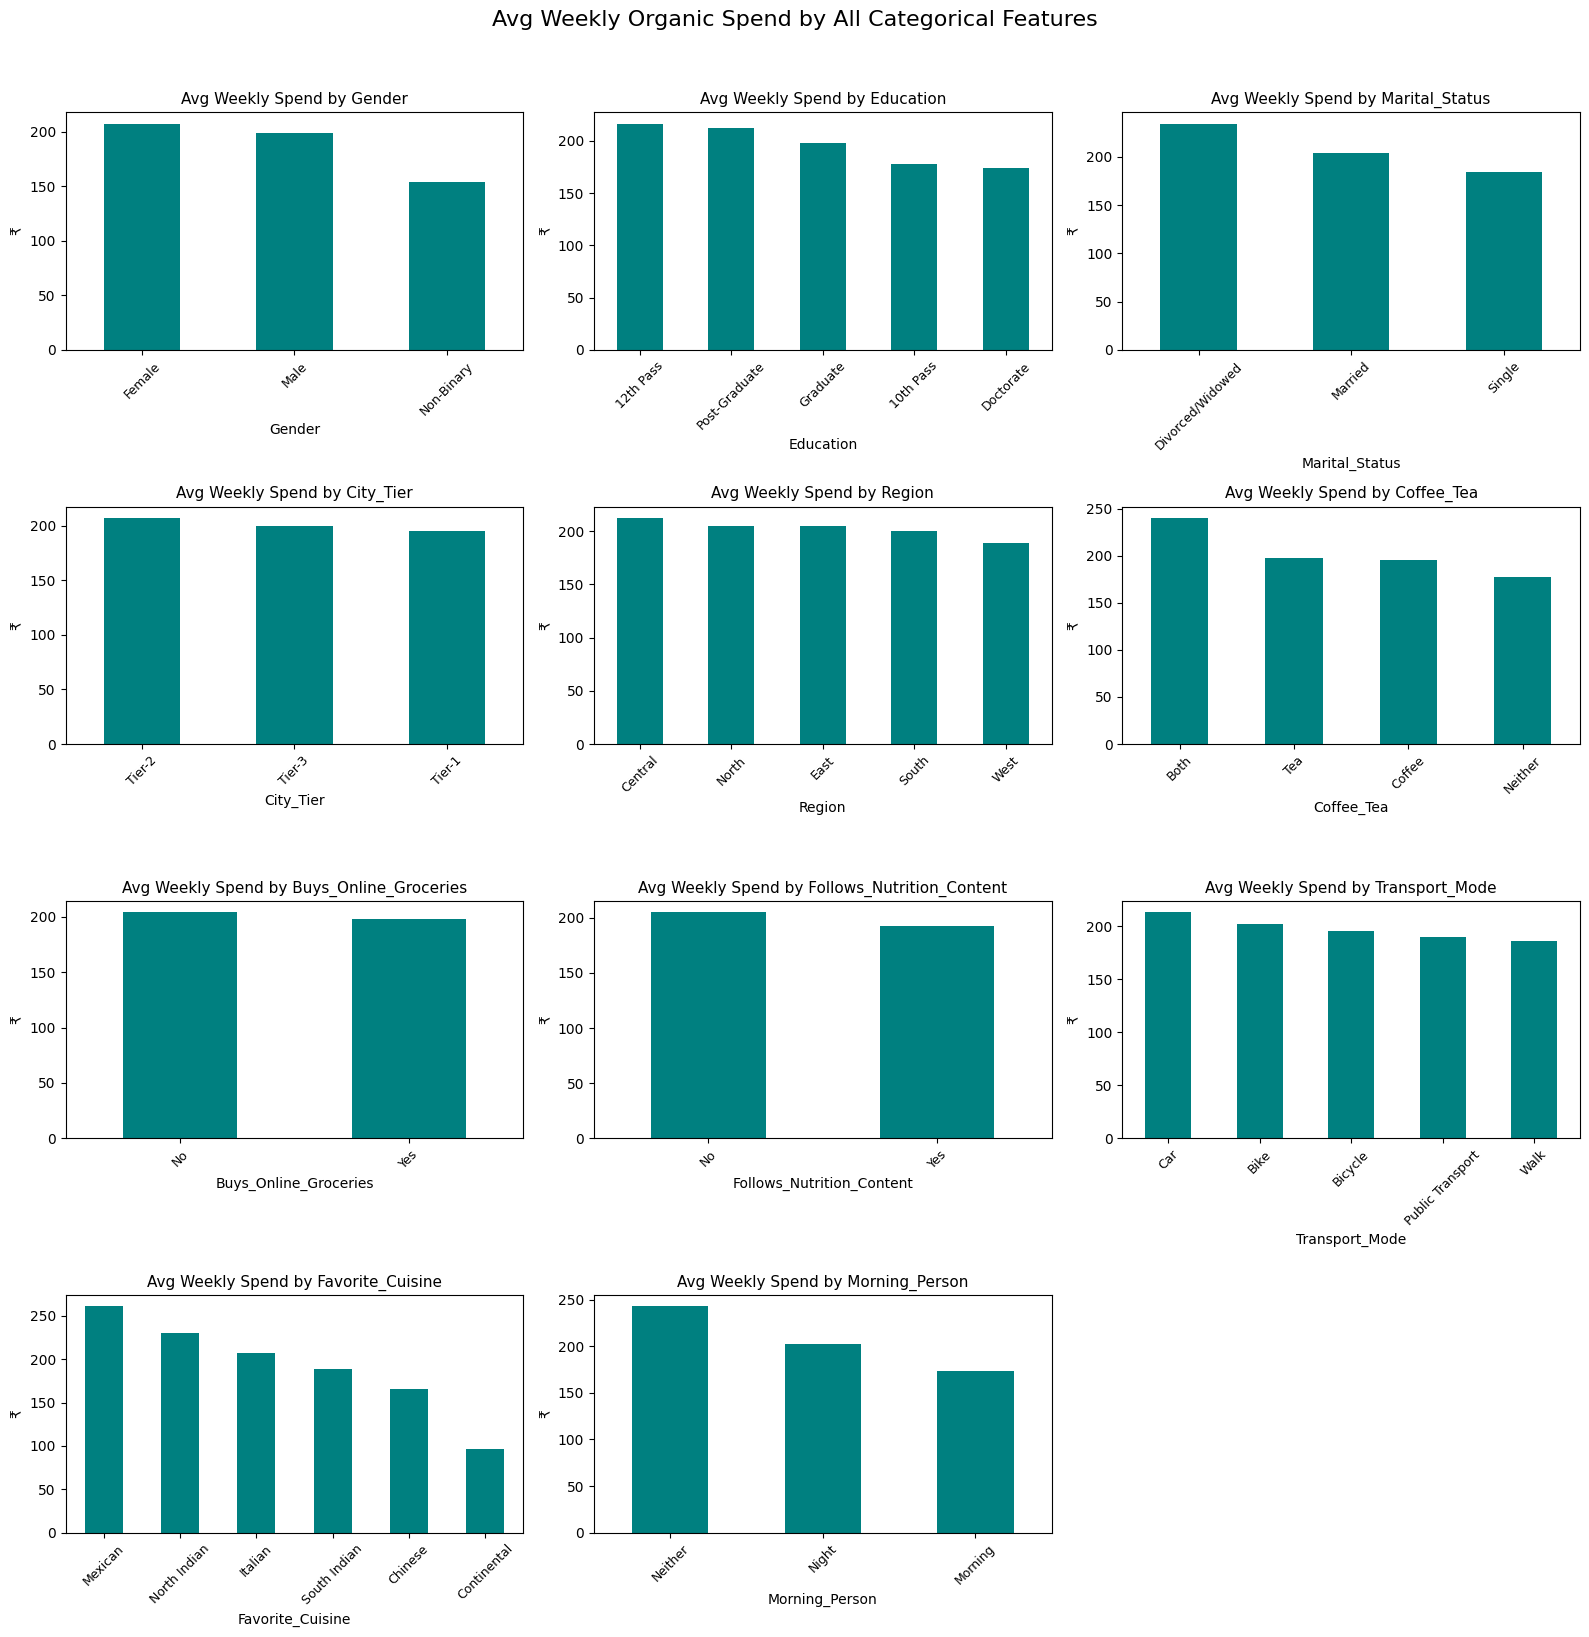

In [12]:
import pandas as pd
import matplotlib.pyplot as plt


# All categorical columns (these are the ones that make sense as bar charts)
cat_cols = ['Gender','Education','Marital_Status','City_Tier','Region','Coffee_Tea',
            'Buys_Online_Groceries','Follows_Nutrition_Content','Transport_Mode',
            'Favorite_Cuisine','Morning_Person']

n = len(cat_cols)
cols = 3
rows = -(-n // cols)  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(16, rows*4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    avg_spend = df.groupby(col)['Weekly_Organic_Spend'].mean().sort_values(ascending=False)
    avg_spend.plot(kind='bar', ax=axes[i], color='teal')
    axes[i].set_title(f'Avg Weekly Spend by {col}', fontsize=11)
    axes[i].set_ylabel('₹')
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)

# turn off unused empty subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Avg Weekly Organic Spend by All Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Purchase Intent Rate by All Categorical Features -> Same layout as above, but shows the % of customers who say **Yes to Purchase Intent** within each category — lets you separate "who wants organic" from "who actually pays for it" across every categorical variable at once.

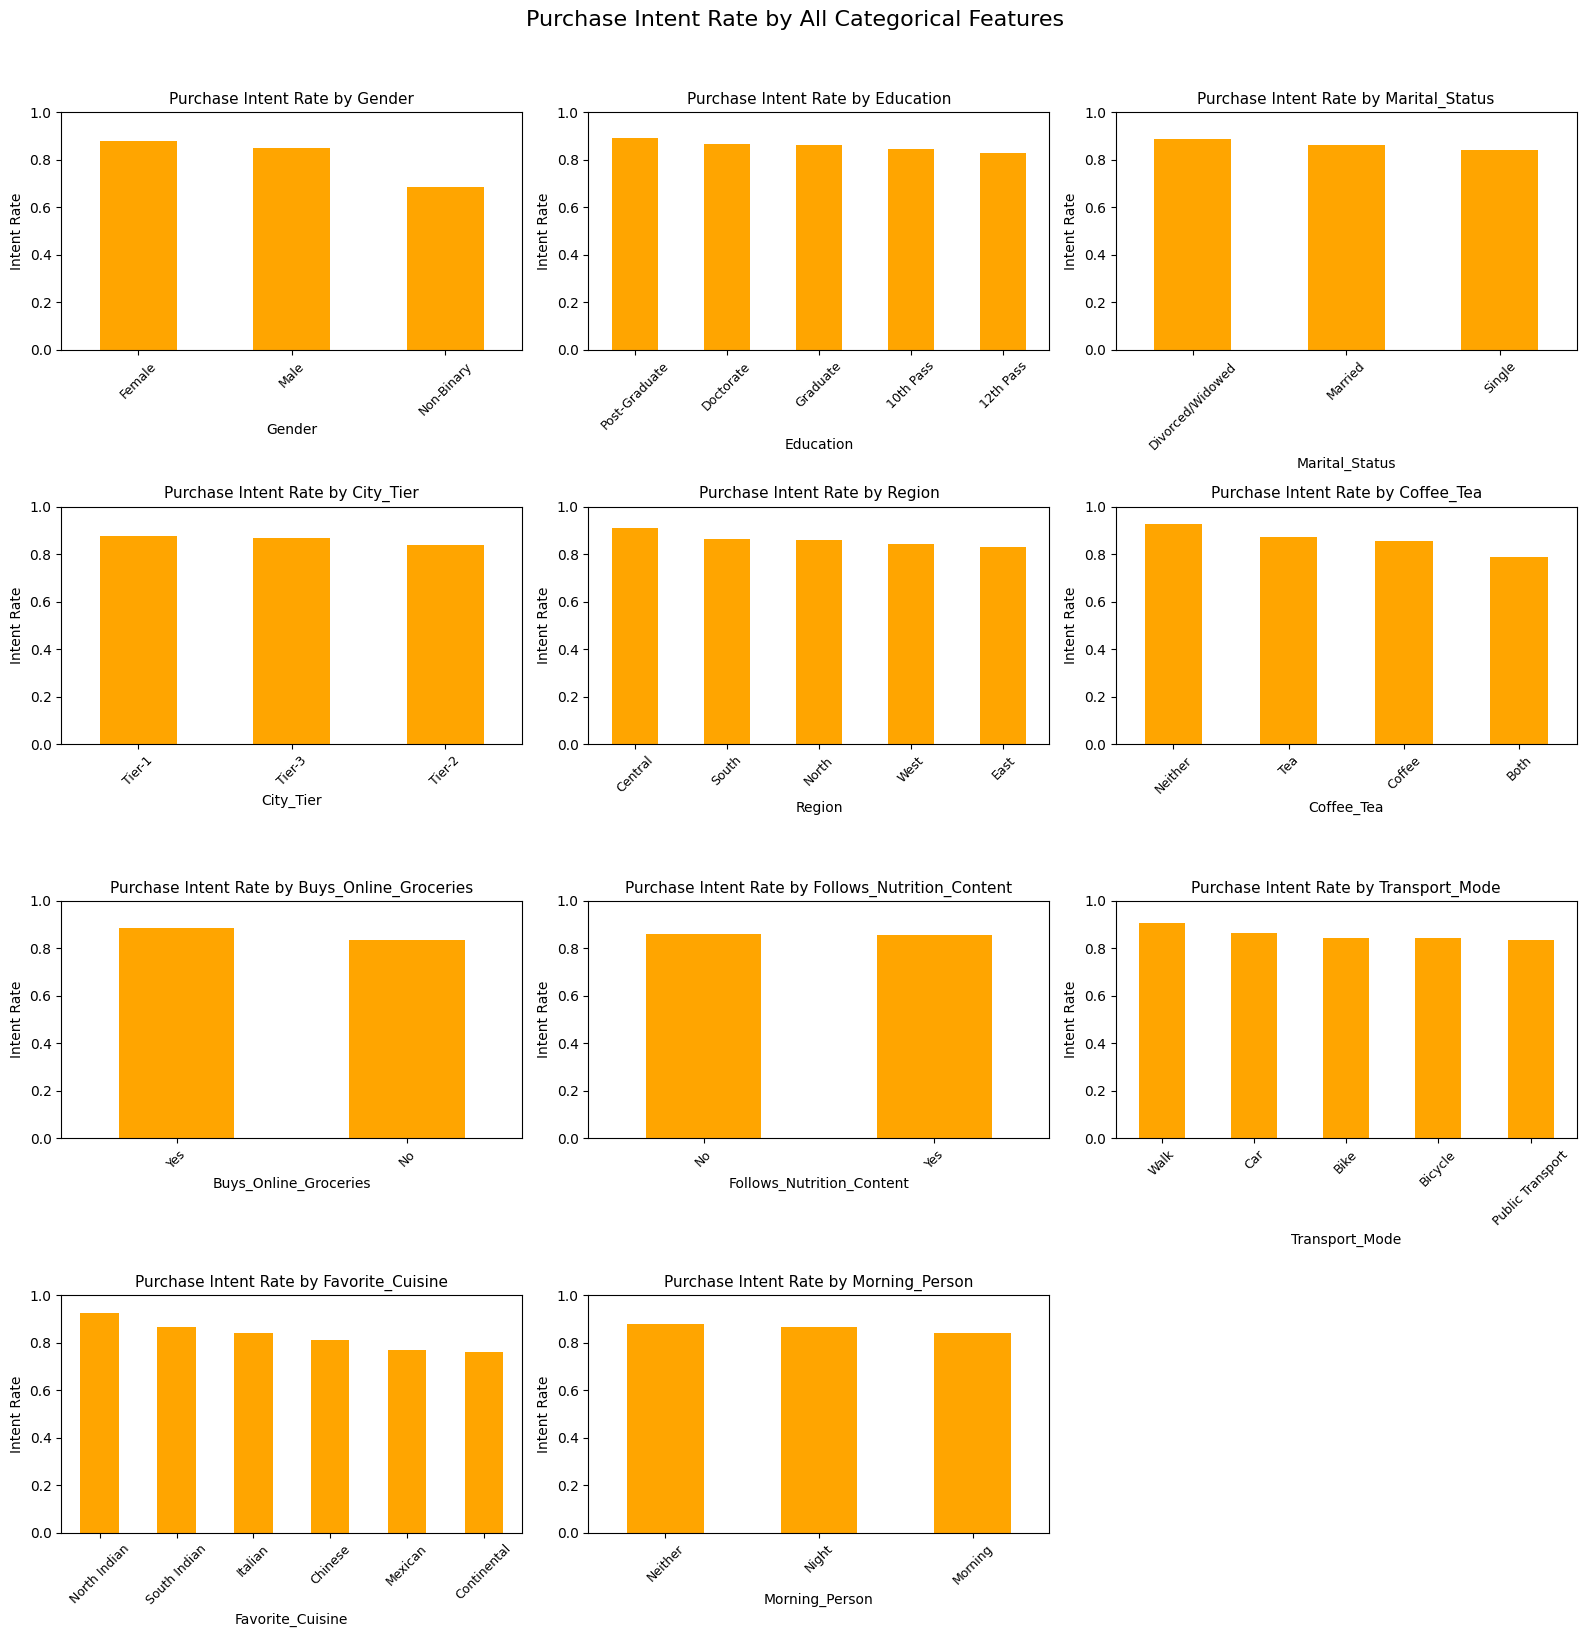

In [13]:
# All categorical columns
cat_cols = ['Gender','Education','Marital_Status','City_Tier','Region','Coffee_Tea',
            'Buys_Online_Groceries','Follows_Nutrition_Content','Transport_Mode',
            'Favorite_Cuisine','Morning_Person']

n = len(cat_cols)
cols = 3
rows = -(-n // cols)  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(16, rows*4))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    intent_rate = df.groupby(col)['Purchase_Intent'].mean().sort_values(ascending=False)
    intent_rate.plot(kind='bar', ax=axes[i], color='orange')
    axes[i].set_title(f'Purchase Intent Rate by {col}', fontsize=11)
    axes[i].set_ylabel('Intent Rate')
    axes[i].set_ylim(0, 1)
    axes[i].tick_params(axis='x', rotation=45, labelsize=9)

# turn off unused empty subplots
for j in range(len(cat_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Purchase Intent Rate by All Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Distribution of All Numeric Features -> One combined figure with a histogram per numeric column — shows the shape (skewed, normal, spread out) of every numeric variable in a single view.

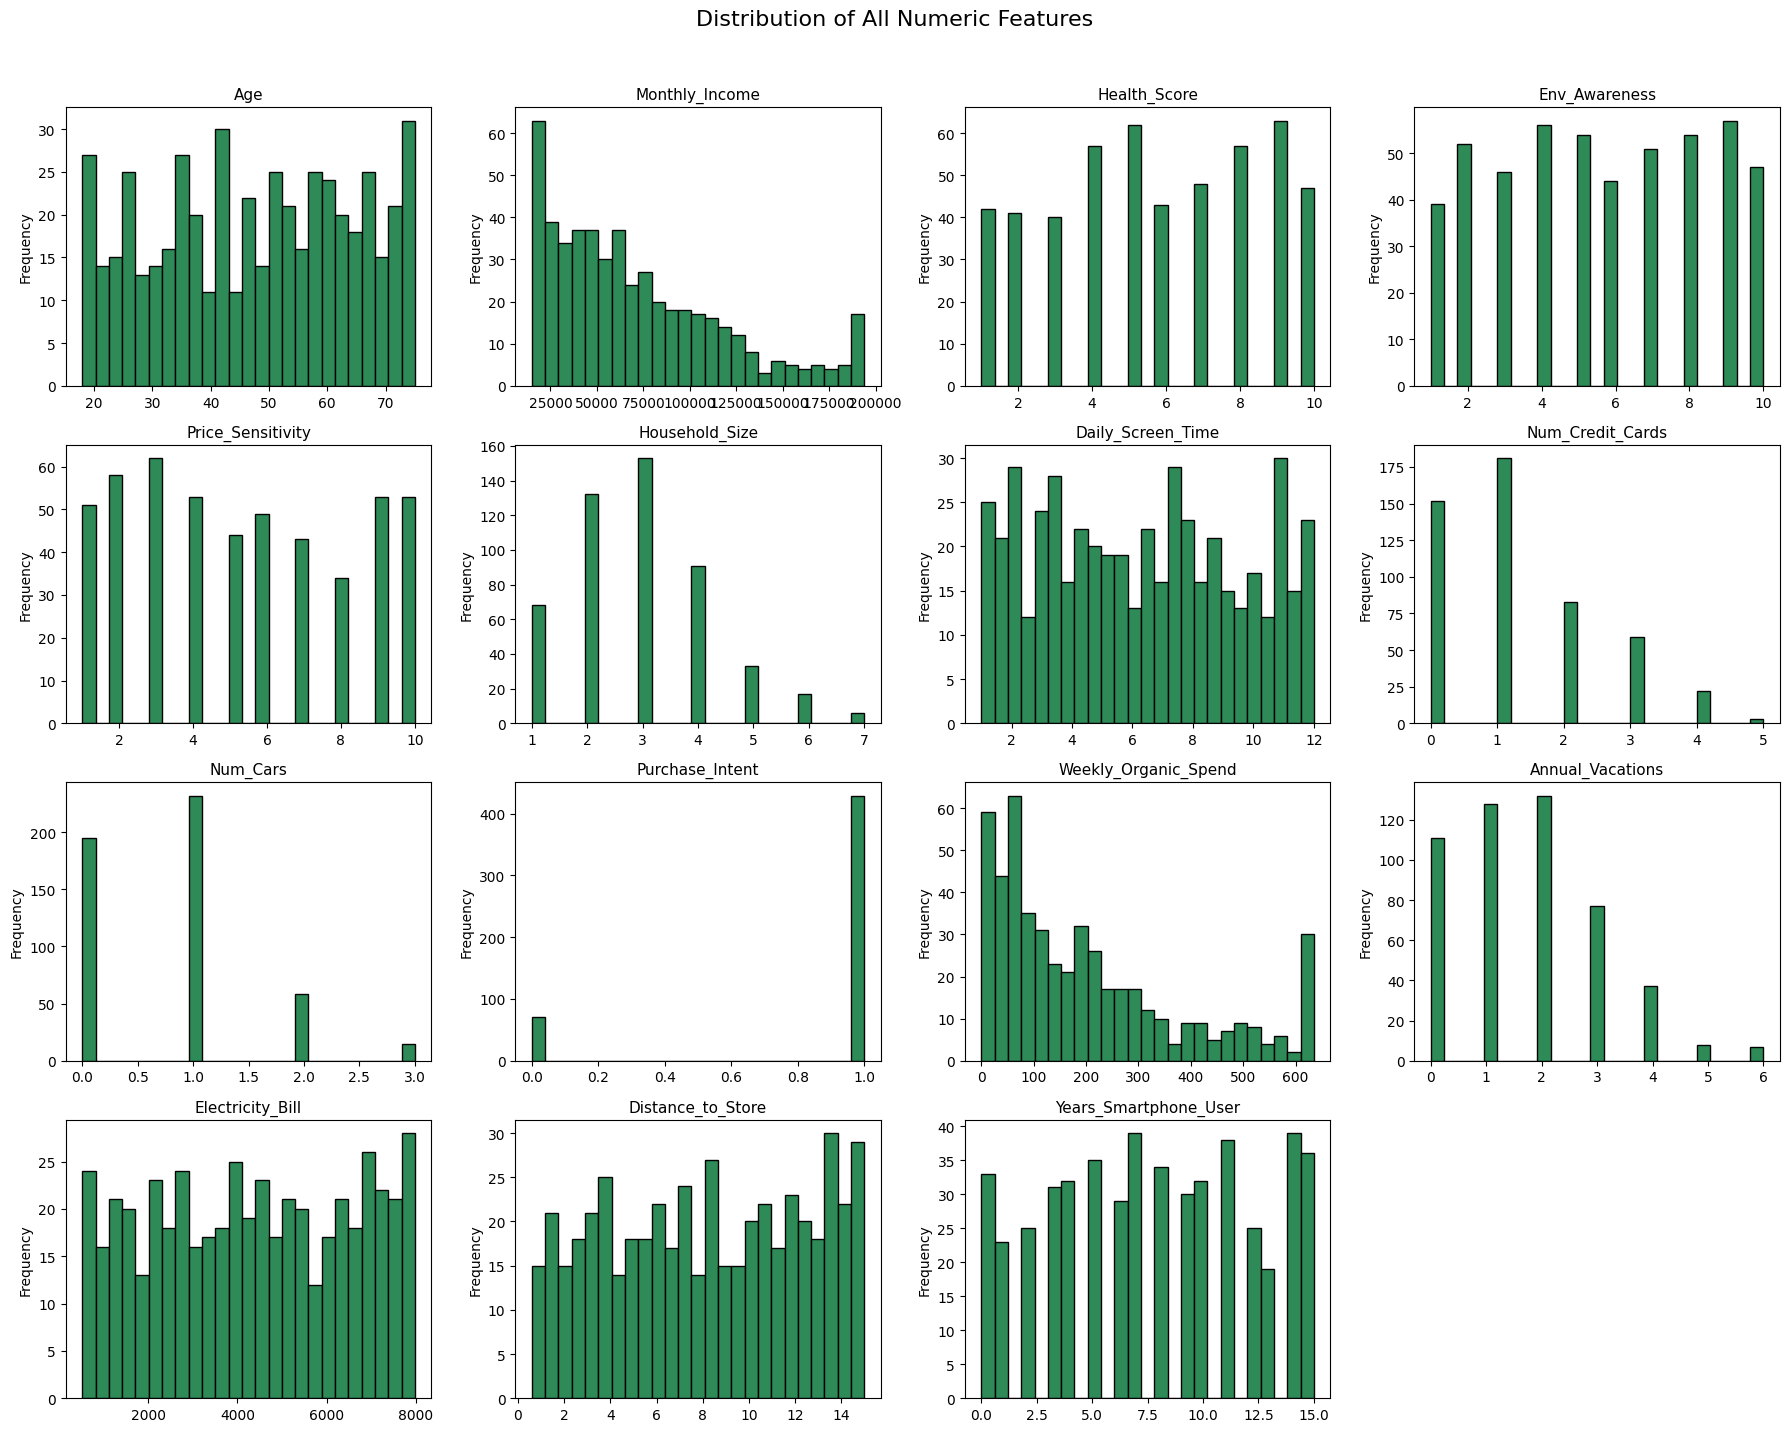

In [14]:
# All numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()

n = len(numeric_cols)
cols = 4
rows = -(-n // cols)  # ceil division

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*3.5))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].plot(kind='hist', bins=25, ax=axes[i], color='seagreen', edgecolor='black')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xlabel('')

# turn off unused empty subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of All Numeric Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Phase 2: Feature Engineering & Selection

In [15]:
# 1. Spend as % of Monthly Income
df['Spend_per_Income'] = df['Weekly_Organic_Spend'] * 4 / (df['Monthly_Income'] + 1)

# 2. Eco-Consciousness Score
df['Eco_Conscious_Score'] = df['Health_Score'] + df['Env_Awareness'] - df['Price_Sensitivity']

# 3. Convenience Gap (distance friction for non-online shoppers)
df['Convenience_Gap'] = df['Distance_to_Store'] * (df['Buys_Online_Groceries'] == 'No').astype(int)

# 4. Affluence Index (composite wealth score)
df['Affluence_Index'] = (df['Monthly_Income']/1000 + df['Num_Cars']*20 +
                          df['Num_Credit_Cards']*10 - df['Electricity_Bill']/500)
# 5. Price Sensitivity relative to Income
df['Income_per_Person'] = df['Monthly_Income'] / df['Household_Size']
df['Price_to_Income'] = df['Price_Sensitivity'] / (df['Income_per_Person'] + 1) * 1000

C:\Users\443pr\AppData\Local\Temp\ipykernel_7280\384791298.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  (df.groupby('Income_Bracket')['Spend_per_Income'].mean()*100).plot(
C:\Users\443pr\AppData\Local\Temp\ipykernel_7280\384791298.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Eco_Bin')['Purchase_Intent'].mean().plot(
C:\Users\443pr\AppData\Local\Temp\ipykernel_7280\384791298.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

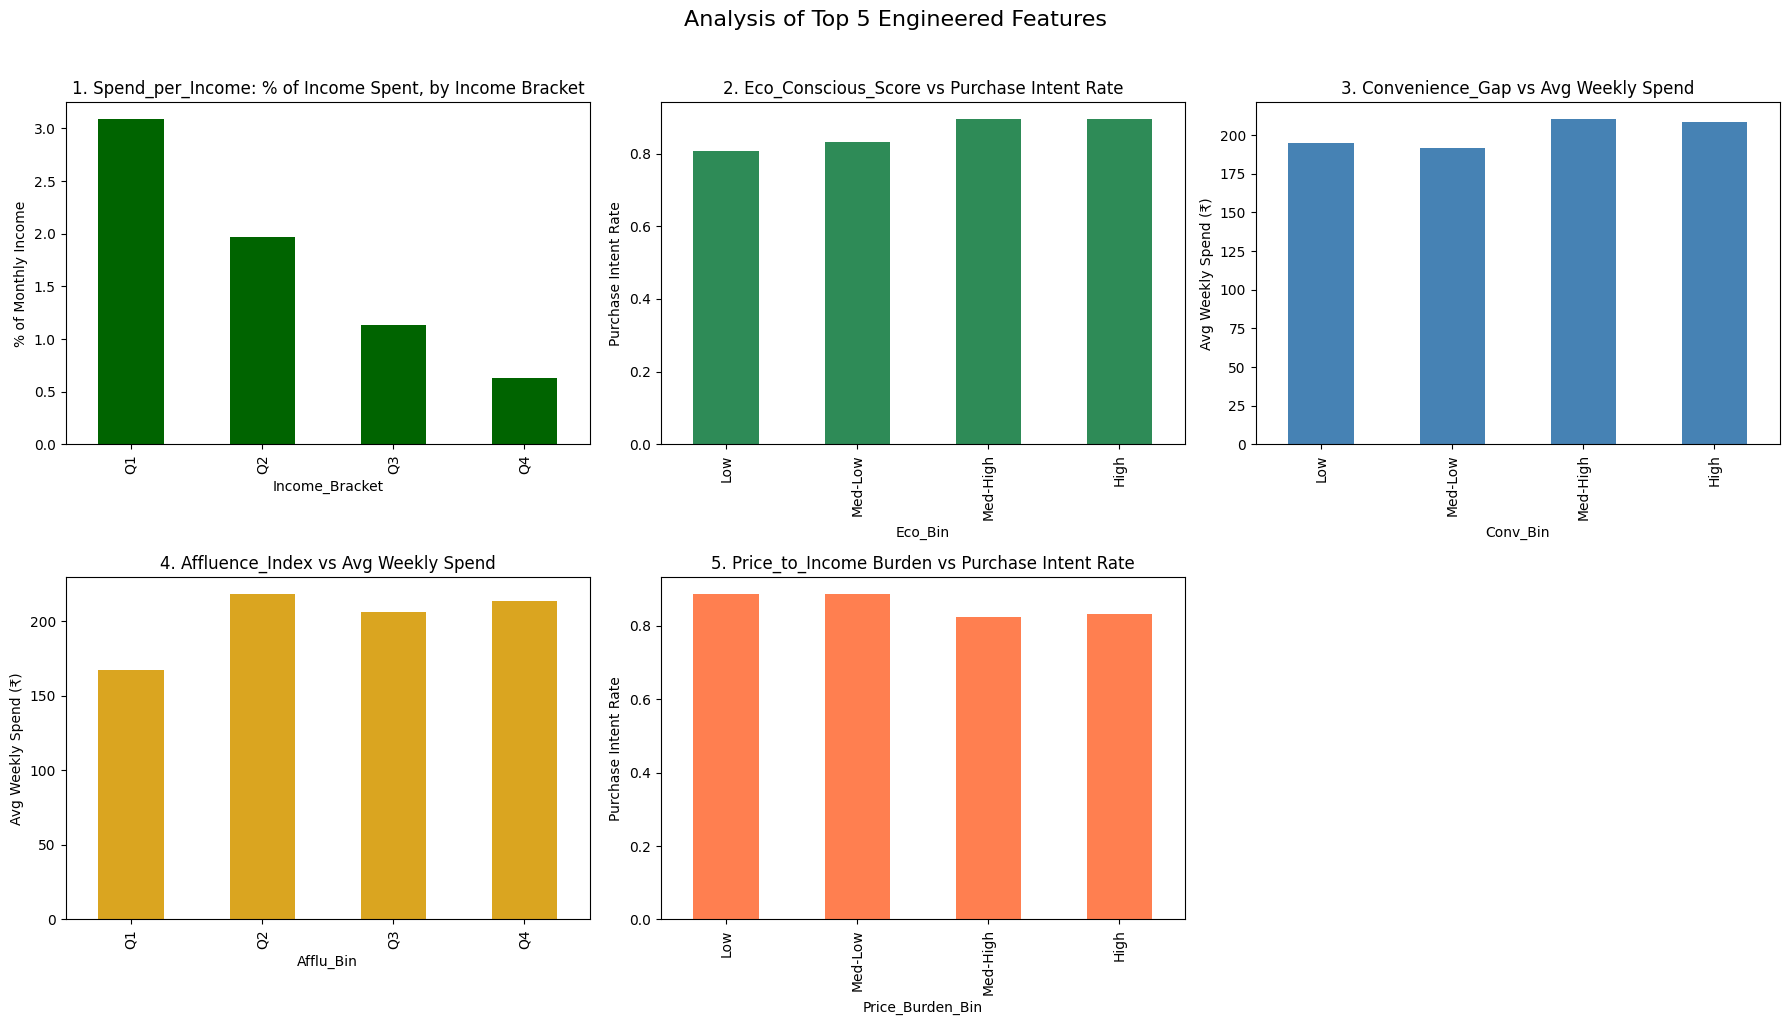

In [16]:
# ---- Bin each into quartiles for clean bar charts ----
df['Income_Bracket']   = pd.qcut(df['Monthly_Income'], 4, labels=['Q1','Q2','Q3','Q4'])
df['Eco_Bin']          = pd.qcut(df['Eco_Conscious_Score'].rank(method='first'), 4, labels=['Low','Med-Low','Med-High','High'])
df['Conv_Bin']         = pd.qcut(df['Convenience_Gap'].rank(method='first'), 4, labels=['Low','Med-Low','Med-High','High'])
df['Afflu_Bin']        = pd.qcut(df['Affluence_Index'].rank(method='first'), 4, labels=['Q1','Q2','Q3','Q4'])
df['Price_Burden_Bin'] = pd.qcut(df['Price_to_Income'].rank(method='first'), 4, labels=['Low','Med-Low','Med-High','High'])

# <------------------------------------------------------------------------------------------------------------------>

# ---- Combine all 5 into ONE figure ----
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

(df.groupby('Income_Bracket')['Spend_per_Income'].mean()*100).plot(
    kind='bar', ax=axes[0], color='darkgreen')
axes[0].set_title('1. Spend_per_Income: % of Income Spent, by Income Bracket')
axes[0].set_ylabel('% of Monthly Income')

df.groupby('Eco_Bin')['Purchase_Intent'].mean().plot(
    kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('2. Eco_Conscious_Score vs Purchase Intent Rate')
axes[1].set_ylabel('Purchase Intent Rate')

df.groupby('Conv_Bin')['Weekly_Organic_Spend'].mean().plot(
    kind='bar', ax=axes[2], color='steelblue')
axes[2].set_title('3. Convenience_Gap vs Avg Weekly Spend')
axes[2].set_ylabel('Avg Weekly Spend (₹)')

df.groupby('Afflu_Bin')['Weekly_Organic_Spend'].mean().plot(
    kind='bar', ax=axes[3], color='goldenrod')
axes[3].set_title('4. Affluence_Index vs Avg Weekly Spend')
axes[3].set_ylabel('Avg Weekly Spend (₹)')

df.groupby('Price_Burden_Bin')['Purchase_Intent'].mean().plot(
    kind='bar', ax=axes[4], color='coral')
axes[4].set_title('5. Price_to_Income Burden vs Purchase Intent Rate')
axes[4].set_ylabel('Purchase Intent Rate')

# <------------------------------------------------------------------------------------------------------------------>

# plotting graph
axes[5].axis('off')  # empty 6th slot (5 features in a 2x3 grid)
plt.suptitle('Analysis of Top 5 Engineered Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Task 3: Business Problem-Solving — Strategic, Analytical & Actionable Framework

Customer segmentation (K-Means) and a segment-to-action table covering shelf placement, marketing, pricing, and inventory.

In [17]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# ---- Feature engineering (from Task 2) used as clustering inputs ----
df['Spend_per_Income']    = df['Weekly_Organic_Spend'] * 4 / (df['Monthly_Income'] + 1)
df['Eco_Conscious_Score'] = df['Health_Score'] + df['Env_Awareness'] - df['Price_Sensitivity']
df['Convenience_Gap']     = df['Distance_to_Store'] * (df['Buys_Online_Groceries'] == 'No').astype(int)
df['Affluence_Index']     = (df['Monthly_Income']/1000 + df['Num_Cars']*20 +
                              df['Num_Credit_Cards']*10 - df['Electricity_Bill']/500)
df['Income_per_Person']   = df['Monthly_Income'] / df['Household_Size']
df['Price_to_Income']     = df['Price_Sensitivity'] / (df['Income_per_Person'] + 1) * 1000

seg_features = ['Spend_per_Income', 'Eco_Conscious_Score', 'Convenience_Gap',
                'Affluence_Index', 'Price_to_Income']

# <------------------------------------------------------------------------------------------------------------------------>

# ---- Segment customers into 4 groups ----
X_seg = StandardScaler().fit_transform(df[seg_features])
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Segment'] = km.fit_predict(X_seg)

# <------------------------------------------------------------------------------------------------------------------------>

# ---- Profile each segment ----
profile = df.groupby('Segment').agg(
    Size=('Segment', 'size'), Avg_Income=('Monthly_Income', 'mean'),
    Avg_Spend=('Weekly_Organic_Spend', 'mean'), Intent_Rate=('Purchase_Intent', 'mean'),
    Avg_SpendPerIncome=('Spend_per_Income', 'mean'), Avg_ConvenienceGap=('Convenience_Gap', 'mean'),
    Avg_EcoScore=('Eco_Conscious_Score', 'mean')
).round(3)

# <------------------------------------------------------------------------------------------------------------------------>

# ---- Name segments in plain business language ----
budget_stretched_id    = profile['Avg_SpendPerIncome'].idxmax()
affluent_id            = profile['Avg_SpendPerIncome'].idxmin()
remaining               = [s for s in profile.index if s not in [budget_stretched_id, affluent_id]]
convenience_blocked_id = profile.loc[remaining, 'Avg_ConvenienceGap'].idxmax()
eco_aspirer_id          = [s for s in remaining if s != convenience_blocked_id][0]

segment_names = {
    budget_stretched_id:    'Budget-Stretched Loyalists',
    affluent_id:            'Affluent Low-Priority',
    convenience_blocked_id: 'Convenience-Blocked Buyers',
    eco_aspirer_id:         'Eco-Conscious Aspirers'
}
df['Segment_Name'] = df['Segment'].map(segment_names)

final_profile = df.groupby('Segment_Name').agg(
    Size=('Segment_Name', 'size'), Avg_Income=('Monthly_Income', 'mean'),
    Avg_Spend=('Weekly_Organic_Spend', 'mean'), Intent_Rate=('Purchase_Intent', 'mean')
).round(2)
final_profile

,Size,Avg_Income,Avg_Spend,Intent_Rate
Segment_Name,,,,
Affluent Low-Priority,116,136027.55,196.91,0.86
Budget-Stretched Loyalists,46,19754.70,300.69,0.87
Convenience-Blocked Buyers,142,56734.85,213.50,0.82
Eco-Conscious Aspirers,196,54090.49,172.08,0.88


In [18]:
# ---- Action table: Segment → Shelf Placement → Marketing → Pricing → Inventory ----
size_map = df['Segment_Name'].value_counts().to_dict()

# <------------------------------------------------------------------------------------------------------------------------>

action_table = pd.DataFrame({
    'Segment': ['Budget-Stretched Loyalists', 'Affluent Low-Priority',
                'Convenience-Blocked Buyers', 'Eco-Conscious Aspirers'],
    'Shelf Placement': [
        'Guarantee availability of core/value-pack organic items',
        'Prominent premium placement near checkout/high-traffic zones',
        'Reduce reliance on physical shelf; invest in online catalog visibility',
        'Prime, easy-access placement near entrance'
    ],
    'Marketing Message': [
        'Health/necessity-focused messaging',
        'Premium lifestyle and convenience messaging',
        'Promote online ordering and delivery',
        'Sustainability and environmental storytelling'
    ],
    'Pricing Strategy': [
        'Smaller/value pack sizes and loyalty discounts',
        'Standard-to-premium pricing with bundling',
        'Standard pricing with discounted delivery',
        'Introduce an accessible mid-tier organic line'
    ],
    'Inventory Decision': [
        'Prioritize affordable core SKUs',
        'Stock a wide, exclusive premium SKU range',
        'Prioritize delivery/online-channel inventory',
        'Increase entry-level/starter organic SKU variety'
    ]
})

# <------------------------------------------------------------------------------------------------------------------------>

action_table.insert(1, 'Size', action_table['Segment'].map(size_map))
action_table

,Segment,Size,Shelf Placement,Marketing Message,Pricing Strategy,Inventory Decision
0,Budget-Stretched Loyalists,46,Guarantee availability of core/value-pack orga...,Health/necessity-focused messaging,Smaller/value pack sizes and loyalty discounts,Prioritize affordable core SKUs
1,Affluent Low-Priority,116,Prominent premium placement near checkout/high...,Premium lifestyle and convenience messaging,Standard-to-premium pricing with bundling,"Stock a wide, exclusive premium SKU range"
2,Convenience-Blocked Buyers,142,Reduce reliance on physical shelf; invest in o...,Promote online ordering and delivery,Standard pricing with discounted delivery,Prioritize delivery/online-channel inventory
3,Eco-Conscious Aspirers,196,"Prime, easy-access placement near entrance",Sustainability and environmental storytelling,Introduce an accessible mid-tier organic line,Increase entry-level/starter organic SKU variety


<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

Visualizing Segment Distribution

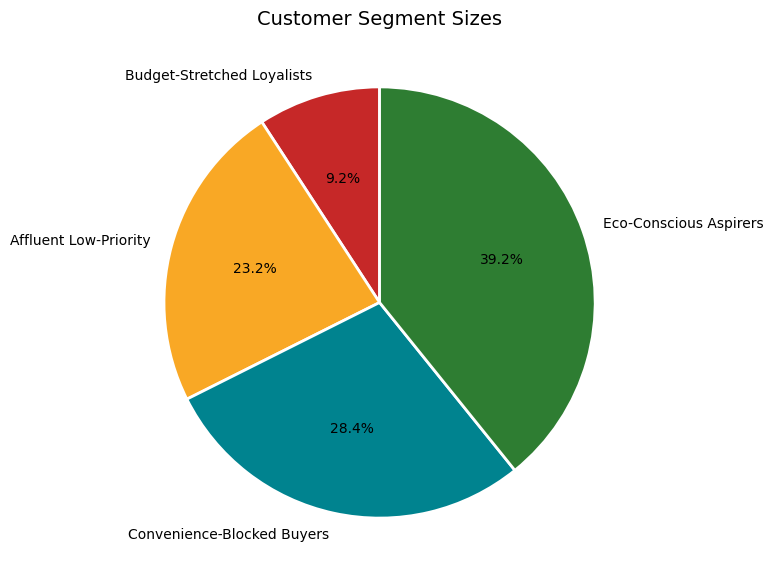

In [19]:
import matplotlib.pyplot as plt

colors = {'Budget-Stretched Loyalists':'#c62828', 'Affluent Low-Priority':'#f9a825',
          'Convenience-Blocked Buyers':'#00838f', 'Eco-Conscious Aspirers':'#2e7d32'}
segment_order = ['Budget-Stretched Loyalists', 'Affluent Low-Priority',
                  'Convenience-Blocked Buyers', 'Eco-Conscious Aspirers']
palette = [colors[s] for s in segment_order]

plt.figure(figsize=(7,7))
df['Segment_Name'].value_counts().reindex(segment_order).plot(
    kind='pie', autopct='%1.1f%%', colors=palette, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2}
)
plt.title('Customer Segment Sizes', fontsize=14)
plt.ylabel('')
plt.show()

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Phase 4: Incisive Insights & Recommendations

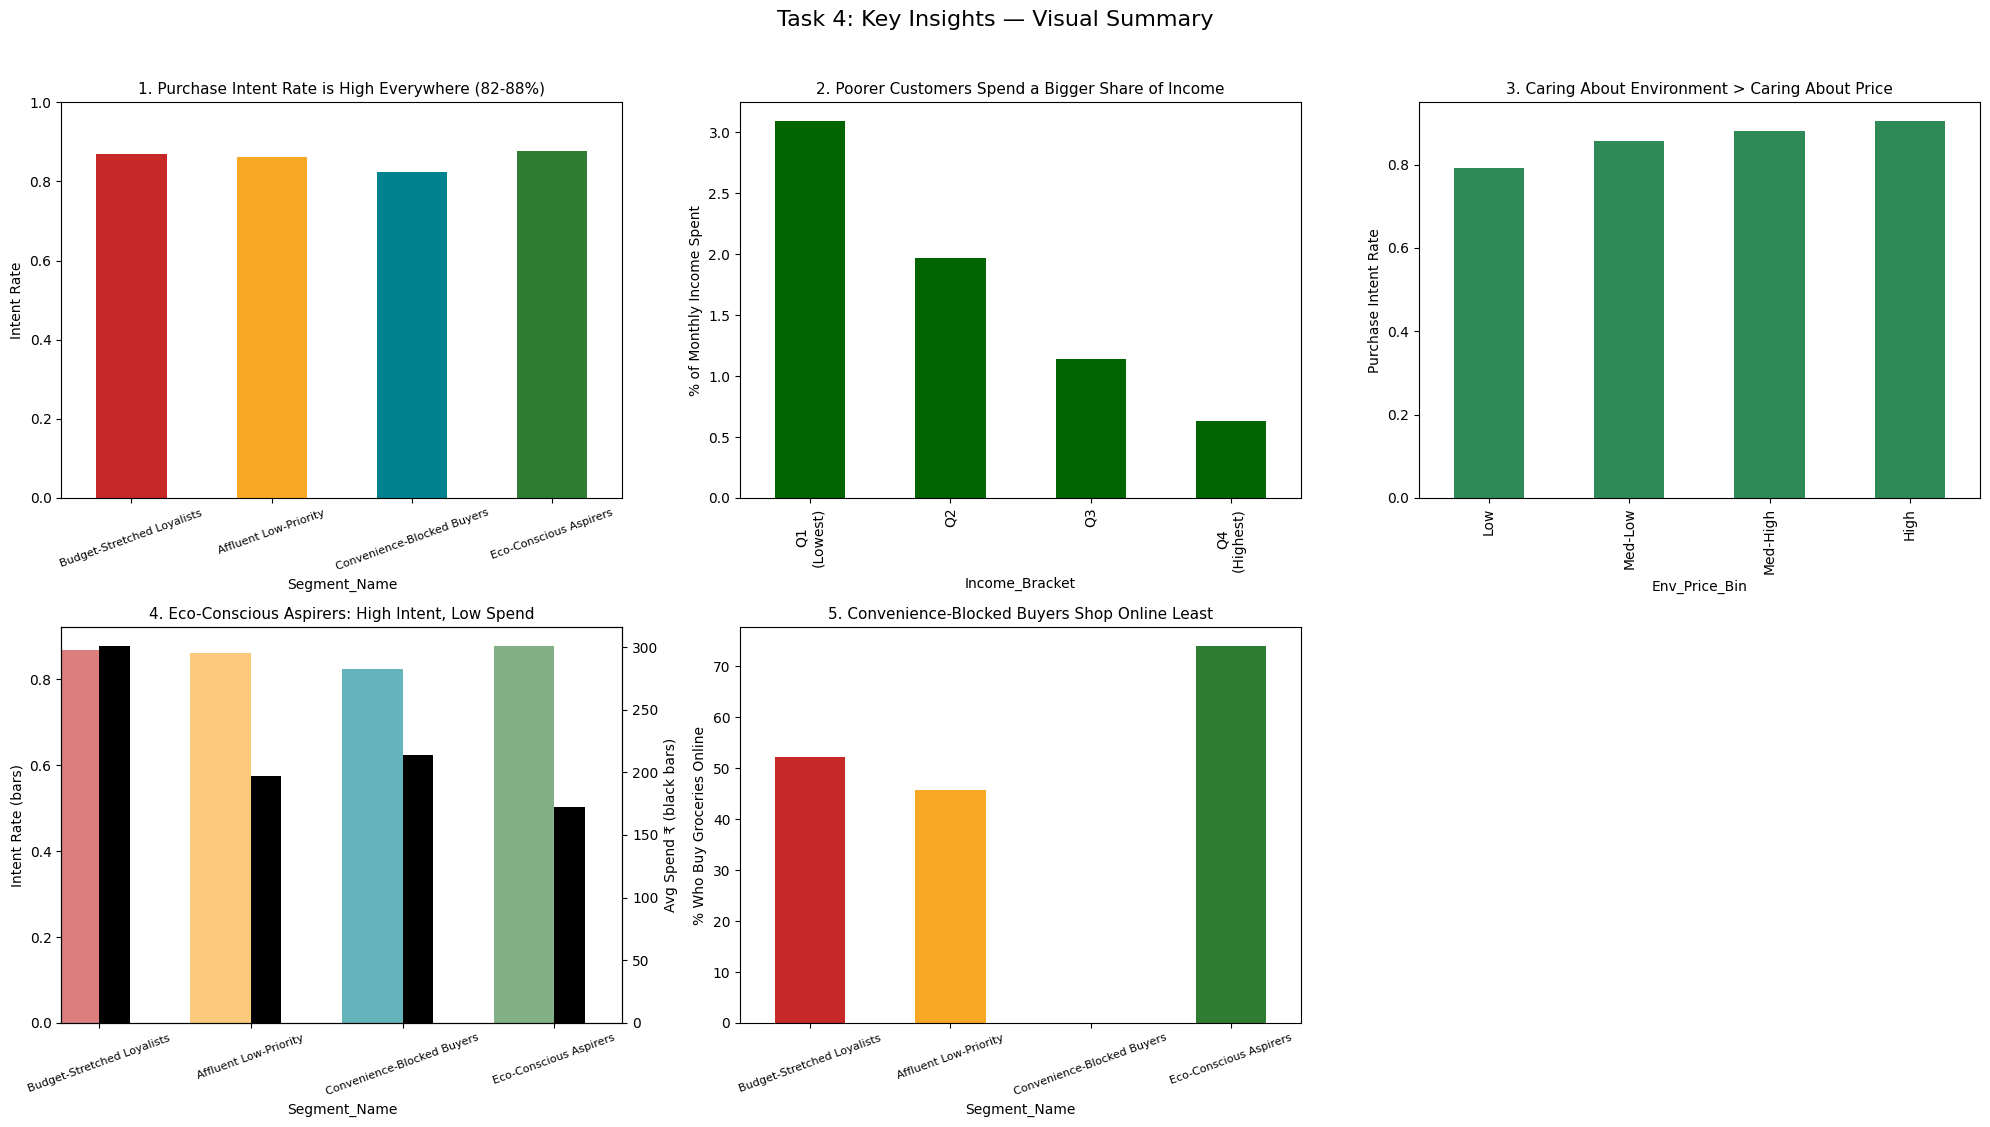


### Explanation of Task 4 Insight Graphs

| Graph | What It Shows (in plain terms) |
|---|---|
| **1. Purchase Intent Rate by Segment** | The % of customers who say "yes, I want organic" in each of the 4 customer groups. Proves almost everyone wants organic (82-88% across all groups) — so wanting it isn't the problem, something else is. |
| **2. Spend as % of Income, by Income Bracket** | What percentage of monthly income customers spend on organic, split by income level. Poorer customers spend a bigger share of income on organic (3.4%) than richer customers (0.6%) — organic feels like more of a priority for them despite having less money. |
| **3. Purchase Intent by Environment-vs-Price Score** | Intent rate for customers grouped by whether they care more about environment or price. Customers who value the environment more than price are far more likely to want organic (90%) than price-focused customers (79%) — values matter more than cost. |
| **4. Eco-Conscious Aspirers: High Intent, Low Spend** | Compares intent rate against actual spend for each segment. Highlights one group that wants organic the most but actually spends the least — a visual proof of the gap between "wanting it" and "buying it." |
| **5. Convenience-Blocked Buyers Shop Online Least** | The % of customers in each segment who shop for groceries online. One segment shops online far less than the others — suggesting distance and lack of delivery options, not lack of interest, is blocking their purchases. |

**Summary:** Together, these 5 graphs show that GreenBazaar's problem isn't that customers don't want organic — it's that price framing, income constraints, and access/convenience are each blocking a different group of customers from converting that desire into an actual purchase.


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
axes = axes.flatten()

segment_order = ['Budget-Stretched Loyalists', 'Affluent Low-Priority',
                  'Convenience-Blocked Buyers', 'Eco-Conscious Aspirers']
colors = {'Budget-Stretched Loyalists':'#c62828', 'Affluent Low-Priority':'#f9a825',
          'Convenience-Blocked Buyers':'#00838f', 'Eco-Conscious Aspirers':'#2e7d32'}
palette = [colors[s] for s in segment_order]

# <------------------------------------------------------------------------------------------------------------------------>

# Insight 1: Purchase Intent by Segment
df.groupby('Segment_Name')['Purchase_Intent'].mean().reindex(segment_order).plot(
    kind='bar', ax=axes[0], color=palette)
axes[0].set_title('1. Purchase Intent Rate is High Everywhere (82-88%)', fontsize=11)
axes[0].set_ylabel('Intent Rate')
axes[0].set_ylim(0,1)
axes[0].tick_params(axis='x', rotation=20, labelsize=8)


# Insight 2: Spend % of Income drops as income rises
df['Income_Bracket'] = pd.qcut(df['Monthly_Income'], 4, labels=['Q1\n(Lowest)','Q2','Q3','Q4\n(Highest)'])
(df.groupby('Income_Bracket', observed=True)['Spend_per_Income'].mean()*100).plot(
    kind='bar', ax=axes[1], color='darkgreen')
axes[1].set_title('2. Poorer Customers Spend a Bigger Share of Income', fontsize=11)
axes[1].set_ylabel('% of Monthly Income Spent')


# Insight 3: Env-consciousness beats price sensitivity
df['Env_minus_Price'] = df['Env_Awareness'] - df['Price_Sensitivity']   # <-- FIX: create this column first
df['Env_Price_Bin'] = pd.qcut(df['Env_minus_Price'].rank(method='first'), 4,
                               labels=['Low','Med-Low','Med-High','High'])
df.groupby('Env_Price_Bin', observed=True)['Purchase_Intent'].mean().plot(
    kind='bar', ax=axes[2], color='seagreen')
axes[2].set_title('3. Caring About Environment > Caring About Price', fontsize=11)
axes[2].set_ylabel('Purchase Intent Rate')


# Insight 4: Intent vs Spend by Segment (the conversion gap)
seg_summary = df.groupby('Segment_Name').agg(
    Intent_Rate=('Purchase_Intent','mean'), Avg_Spend=('Weekly_Organic_Spend','mean')
).reindex(segment_order)
ax4 = axes[3]
ax4b = ax4.twinx()
seg_summary['Intent_Rate'].plot(kind='bar', ax=ax4, color=palette, alpha=0.6, width=0.4, position=1)
seg_summary['Avg_Spend'].plot(kind='bar', ax=ax4b, color='black', width=0.2, position=0)
ax4.set_title('4. Eco-Conscious Aspirers: High Intent, Low Spend', fontsize=11)
ax4.set_ylabel('Intent Rate (bars)')
ax4b.set_ylabel('Avg Spend ₹ (black bars)')
ax4.tick_params(axis='x', rotation=20, labelsize=8)


# Insight 5: Distance & Online shopping by segment
conv = df.groupby('Segment_Name').agg(
    Avg_Distance=('Distance_to_Store','mean'),
    Pct_Online=('Buys_Online_Groceries', lambda s: (s=='Yes').mean()*100)
).reindex(segment_order)
conv['Pct_Online'].plot(kind='bar', ax=axes[4], color=palette)
axes[4].set_title('5. Convenience-Blocked Buyers Shop Online Least', fontsize=11)
axes[4].set_ylabel('% Who Buy Groceries Online')
axes[4].tick_params(axis='x', rotation=20, labelsize=8)

# <------------------------------------------------------------------------------------------------------------------------>


axes[5].axis('off')
plt.suptitle('Task 4: Key Insights — Visual Summary', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# <------------------------------------------------------------------------------------------------------------------------>

print('\n')
insight_explanations_md = """
### Explanation of Task 4 Insight Graphs

| Graph | What It Shows (in plain terms) |
|---|---|
| **1. Purchase Intent Rate by Segment** | The % of customers who say "yes, I want organic" in each of the 4 customer groups. Proves almost everyone wants organic (82-88% across all groups) — so wanting it isn't the problem, something else is. |
| **2. Spend as % of Income, by Income Bracket** | What percentage of monthly income customers spend on organic, split by income level. Poorer customers spend a bigger share of income on organic (3.4%) than richer customers (0.6%) — organic feels like more of a priority for them despite having less money. |
| **3. Purchase Intent by Environment-vs-Price Score** | Intent rate for customers grouped by whether they care more about environment or price. Customers who value the environment more than price are far more likely to want organic (90%) than price-focused customers (79%) — values matter more than cost. |
| **4. Eco-Conscious Aspirers: High Intent, Low Spend** | Compares intent rate against actual spend for each segment. Highlights one group that wants organic the most but actually spends the least — a visual proof of the gap between "wanting it" and "buying it." |
| **5. Convenience-Blocked Buyers Shop Online Least** | The % of customers in each segment who shop for groceries online. One segment shops online far less than the others — suggesting distance and lack of delivery options, not lack of interest, is blocking their purchases. |

**Summary:** Together, these 5 graphs show that GreenBazaar's problem isn't that customers don't want organic — it's that price framing, income constraints, and access/convenience are each blocking a different group of customers from converting that desire into an actual purchase.
"""

from IPython.display import Markdown, display
display(Markdown(insight_explanations_md))

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Phase 5 : Predictive Model - Customer Intent Prediction

In [21]:
from sklearn.model_selection import train_test_split

# Drop redundant binned/bracket columns created only for visualization (Task 2/4) -
bin_cols_to_drop = ['Income_Bracket', 'Eco_Bin', 'Conv_Bin', 'Afflu_Bin', 'Price_Burden_Bin']
df_model = df.drop(columns=[c for c in bin_cols_to_drop if c in df.columns])

# <------------------------------------------------------------------------------------------------------------------------>

# Define xp (features) and yp (target)
xp = df_model.drop('Purchase_Intent', axis=1)
yp = df_model['Purchase_Intent']

# <------------------------------------------------------------------------------------------------------------------------>

# Train-test split (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(
    xp, yp, test_size=0.2, random_state=42
)

Scaling Numerical Data and Encoding Categorical Data Using ColumnTransformer

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Identify numerical and categorical columns
num_cols = xp.select_dtypes(include='number').columns.tolist()
cat_cols = xp.select_dtypes(exclude='number').columns.tolist()

# <------------------------------------------------------------------------------------------------------------------------>

# Create the ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Fit on training data, transform both train and test
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

## Building a Stacking Ensemble Model

- **Random Forest Classifier** – Base Model
- **Gradient Boosting Classifier** – Base Model
- **XGBoost Classifier** – Base Model
- **CatBoost Classifier** – Base Model
- **LightGBM Classifier** – Base Model
- **Ridge Classifier** – Meta Model

The predictions from the base models are combined and passed to the Ridge Classifier to generate the final prediction.

In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
import xgboost as xgb
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# ---- Base models
base_models = [
    ('rf',   RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=4, random_state=42)),
    ('xgb',  xgb.XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.04,
                                 subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)),
    ('cat',  CatBoostClassifier(iterations=200, depth=4, learning_rate=0.04, verbose=0, random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.04, random_state=42, verbosity=-1)),
    ('gb',   GradientBoostingClassifier(n_estimators=150, max_depth=3, learning_rate=0.04,
                                          subsample=0.8, random_state=42)),
]

## Training and Evaluating the Stacking Classifier

In this section, we build and evaluate the stacking ensemble model using 5-fold stratified cross-validation.

### Model Configuration

- **Base Models:** Random Forest, Gradient Boosting, XGBoost, CatBoost, and LightGBM
- **Meta Model:** Ridge Classifier
- **Regularization:** `alpha = 10` to reduce the risk of overfitting
- **Cross-Validation:** 5-fold `StratifiedKFold`
- **Passthrough:** Disabled to use only the predictions generated by the base models

### Cross-Validation

The model is evaluated using cross-validation on the training data before accessing the test set. This provides a reliable estimate of model performance and helps prevent data leakage.

### Final Model Evaluation

After cross-validation, the stacking model is trained on the complete training dataset and evaluated on the unseen test dataset.

Since `RidgeClassifier` does not provide probability estimates, its `decision_function()` is used to obtain the confidence scores for the predictions.

In [24]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# ---- Meta model: Ridge with higher alpha = stronger regularization = less overfitting ----
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=RidgeClassifier(alpha=10),
    cv=skf,        # each base model's meta-features are generated out-of-fold, prevents leakage
    passthrough=False,
    n_jobs=-1
)

# ---- Cross-validated performance check (before touching test set) ----
cv_scores = cross_val_score(stack_model, x_train_processed, y_train, cv=skf, scoring='accuracy')

# ---- Fit on full training set, evaluate on hold-out test set ----
stack_model.fit(x_train_processed, y_train)
pred = stack_model.predict(x_test_processed)
score = stack_model.decision_function(x_test_processed)   # RidgeClassifier has no predict_proba, use decision_function

C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: U

## Model Performance Evaluation

In this section, we evaluate the performance of the stacking ensemble using multiple classification metrics on both cross-validation and unseen test data.

### Evaluation Metrics

- **Cross-Validation Accuracy** – Measures the average accuracy across the 5 cross-validation folds.
- **Test Accuracy** – Measures the proportion of correctly classified samples in the test dataset.
- **F1 Score** – Provides a balance between precision and recall, especially useful for classification performance evaluation.
- **ROC-AUC Score** – Measures the model's ability to distinguish between different classes using the decision scores.
- **Confusion Matrix** – Shows the number of correct and incorrect predictions for each class.
- **Classification Report** – Provides precision, recall, F1-score, and support for each class.

The model's cross-validation performance is compared with its test-set performance to assess its generalization capability and identify potential overfitting.

In [25]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print("Test Accuracy:", accuracy_score(y_test, pred))
print("Test F1 Score:", f1_score(y_test, pred))
print("Test ROC-AUC:", roc_auc_score(y_test, score))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, pred))
print("\nClassification Report:\n", classification_report(y_test, pred))

CV Accuracy: 0.8500 (+/- 0.0079)
Test Accuracy: 0.88
Test F1 Score: 0.9361702127659575
Test ROC-AUC: 0.7035984848484849

Confusion Matrix:
 [[ 0 12]
 [ 0 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.88      1.00      0.94        88

    accuracy                           0.88       100
   macro avg       0.44      0.50      0.47       100
weighted avg       0.77      0.88      0.82       100



C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\443pr\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

<-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------->

## Conclusion Summary

**1) What Business Problem GreenBazaar Is Facing**
- Organic food contributes only **4% of total sales**, far below the industry benchmark of **12%** — despite operating in a market growing at **25% CAGR**
- This gap represents an estimated **₹50 crore in lost annual revenue**
- Root cause isn't lack of customer interest — purchase intent is **82-88% across all customer types** — the problem is **conversion, access, and communication**, not demand

**2) Major Factors GreenBazaar Should Focus On**
- **Conversion over awareness** — most customers already want organic; the priority is removing what's stopping intent from becoming a purchase
- **Value communication over price cuts** — customers who value environment/health over price convert at 90% vs 79% for price-driven customers; the fix is better storytelling, not blanket discounts
- **Geographic reallocation** — Tier-2 cities outspend Tier-1 by 9%, yet investment (shelf space, marketing) is typically metro-weighted
- **Access and convenience** — a meaningful customer segment is held back by distance-to-store and lack of online shopping options, not affordability or desire

**3) Keys to Improve Growth & Become Profitable**
- Move from a **one-size-fits-all** organic strategy to a **segment-specific** one (as shown in the action table)
- Introduce a **mid-tier product line** — many high-intent customers aren't converting simply because premium pricing is their only option
- Invest in **delivery/click-and-collect** for convenience-blocked customers rather than more premium in-store space
- **Protect access** for already-loyal, budget-conscious customers rather than deprioritizing them — they're a small but highly committed segment
- Run a **pilot program**: reallocate shelf space and marketing budget in 5-10 stores based on segment insights, and measure the actual lift in organic sales' share before a full rollout

**4) Which Customers to Target — Priority Order**
1. **Eco-Conscious Aspirers** (largest segment, 196 customers) — highest intent, lowest spend → **biggest revenue opportunity**, needs a mid-tier product to convert
2. **Convenience-Blocked Buyers** (142 customers) — held back by access, not desire → needs delivery/online investment
3. **Affluent Low-Priority** (116 customers) — has money, lacks priority → needs premium positioning/bundling to earn share of wallet
4. **Budget-Stretched Loyalists** (46 customers) — smallest group but most committed relative to income → protect, don't ignore

**5) More — Final Takeaways**
- The data shows organic buying behavior is driven more by **values and access** than by **income alone** — a customer's wealth doesn't reliably predict their organic spend
- GreenBazaar's four operational gaps (shelf space, marketing, inventory, pricing) each map cleanly to a specific customer segment — this analysis turns a vague ₹50 crore problem into **four concrete, testable actions**
- Recommendations should be treated as **directional, not definitive** — this analysis is based on customer survey-style data; validating findings against real transaction/POS data before a full strategic rollout is strongly advised